In [1]:
import random
import numpy as np
from PIL import Image
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

from torch.utils.data import DataLoader, Dataset, random_split, \
WeightedRandomSampler, SubsetRandomSampler

from torchvision.transforms import Compose, ToTensor, Normalize,\
ToPILImage, RandomHorizontalFlip, Resize

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

from StepByStep import StepByStep

I0000 00:00:1782228454.542301   75410 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782228454.627920   75410 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782228456.742325   75410 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782228456.743164   75410 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Hepler Functions

In [2]:
class TransformedTensorDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = y
        self.transform = transform

    def __getitem__(self, index):
        x = self.x[index]
        if self.transform:
            x = self.transform(x)

        return x, self.y[index]
    
    def __len__(self):
        return len(self.x)


def index_splitter(n, splits, seed=0):
    idx = torch.arange(n)
    splits_tensor = torch.as_tensor(splits)
    multiplier = n / splits_tensor.sum()
    splits_tensor = (multiplier * splits_tensor).long()

    diff = n - splits_tensor.sum()
    splits_tensor[0] += diff
    
    torch.manual_seed(seed)
    return random_split(idx, splits_tensor)


def make_balanced_sampler(y):
    classes, counts = y.unique(return_counts=True)
    weights = 1.0 / counts.float()
    sample_weights = weights[y.squeeze().long()]
    generator = torch.Generator()
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        generator=generator,
        replacement=True,
    )
    return sampler

In [3]:
%run -i data_prepration/v3.py

<class 'PIL.Image.Image'>


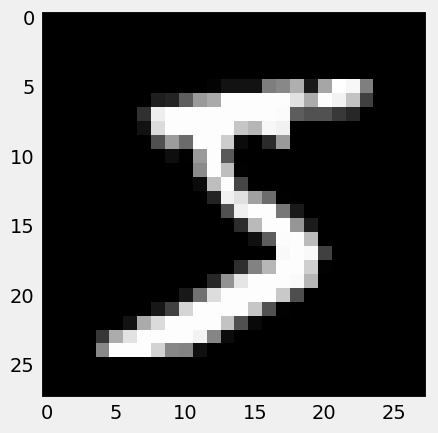

In [4]:
example_img = ToPILImage()(x_train_tensor[0])
print(type(example_img))

plt.imshow(example_img, cmap='gray')
plt.grid(False)

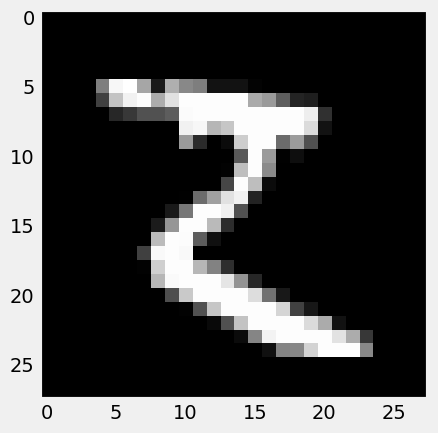

In [5]:
flipper = RandomHorizontalFlip(p=1.0)
flipped_img = flipper(example_img)
plt.imshow(flipped_img, cmap='gray')
plt.grid(False)

In [6]:
train_dataset

In [7]:
x_train_tensor.shape

torch.Size([60000, 1, 28, 28])

### Model Configuration

In [8]:
lr = 0.1

torch.manual_seed(13)

model_logistic = nn.Sequential()
model_logistic.add_module('flatten', nn.Flatten())
model_logistic.add_module('output', nn.Linear(784, 1, bias=False))
model_logistic.add_module('sigmoid', nn.Sigmoid())

optimizer_logistics = optim.SGD(
    model_logistic.parameters(), lr=lr,
)

binary_loss_function = nn.BCELoss() # binary cross entropy loss function

In [9]:
n_epochs = 100

sbs_logistic = StepByStep(
    model=model_logistic,
    loss_function=binary_loss_function,
    optimizer=optimizer_logistics,
)
sbs_logistic.set_loaders(train_loader, val_loader)
sbs_logistic.train(n_epochs)

/home/hananeh/anaconda3/envs/pytorchbook/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Running epoch num 10/100
Running epoch num 20/100
Running epoch num 30/100
Running epoch num 40/100
Running epoch num 50/100
Running epoch num 60/100
Running epoch num 70/100
Running epoch num 80/100
Running epoch num 90/100
Running epoch num 100/100


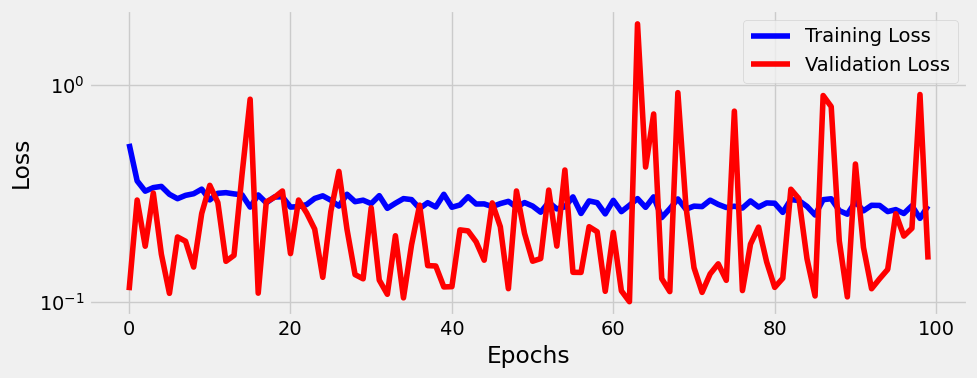

In [10]:
fig = sbs_logistic.plot_losses()

In [ ]:
lr = 0.1

torch.manual_seed(13)

model_nn = nn.Sequential()
model_nn.add_module('flatten', nn.Flatten())
model_nn.add_module('hidden0', nn.Linear(784, 28, bias=False))
model_nn.add_module('hidden1', nn.Linear(28, 3, bias=False))
model_nn.add_module('output', nn.Linear(3, 1, bias=False))
model_nn.add_module('sigmoid', nn.Sigmoid())

optimizer_nn = optim.SGD(
    model_nn.parameters(), lr=lr,
)

binary_loss_function = nn.BCELoss()

In [ ]:
n_epochs = 100

sbs_nn = StepByStep(
    model=model_nn,
    loss_function=binary_loss_function,
    optimizer=optimizer_nn,
)
sbs_nn.set_loaders(train_loader, val_loader)
sbs_nn.train(n_epochs)

In [ ]:
fig = sbs_nn.plot_losses()

In [ ]:
w_nn_hidden0.shape

In [11]:
lr = 0.1

torch.manual_seed(13)

model_relu = nn.Sequential()
model_relu.add_module('flatten', nn.Flatten())
model_relu.add_module('hidden0', nn.Linear(784, 28, bias=False))
model_relu.add_module('activation0', nn.ReLU())
model_relu.add_module('hidden1', nn.Linear(28, 3, bias=False))
model_relu.add_module('activation1', nn.ReLU())
model_relu.add_module('output', nn.Linear(3, 1, bias=False))
model_relu.add_module('sigmoid', nn.Sigmoid())

optimizer_relu = optim.SGD(
    model_relu.parameters(), lr=lr,
)

binary_loss_function = nn.BCELoss()

In [ ]:
n_epochs = 100

sbs_relu = StepByStep(
    model=model_relu,
    loss_function=binary_loss_function,
    optimizer=optimizer_relu,
)
sbs_relu.set_loaders(train_loader, val_loader)
sbs_relu.train(n_epochs)

In [ ]:
fig = sbs_relu.plot_losses()